In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/economic_data.db")
df = pd.read_sql("SELECT * FROM observations", conn)
conn.close()

df.head()

,series_id,date,value
0,IR3TIB01AUM156N,2015-01-01,2.7
1,IR3TIB01AUM156N,2015-02-01,2.36
2,IR3TIB01AUM156N,2015-03-01,2.3
3,IR3TIB01AUM156N,2015-04-01,2.25
4,IR3TIB01AUM156N,2015-05-01,2.15


In [6]:
df['date'] = pd.to_datetime(df['date'])
df['value'] = pd.to_numeric(df['value'], errors='coerce')

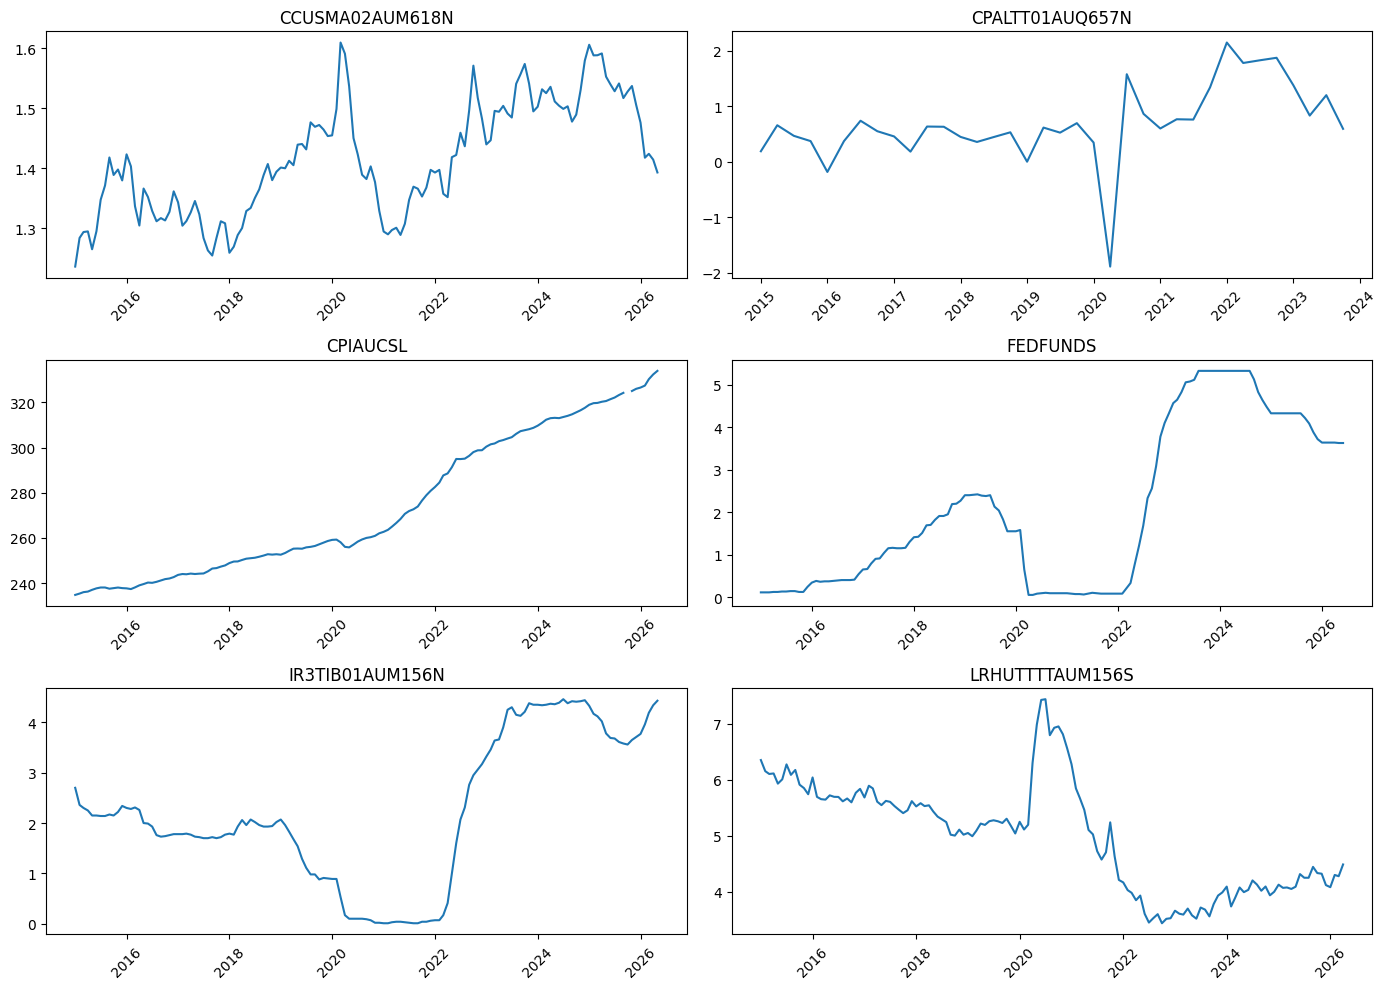

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (sid, group) in zip(axes, df.groupby("series_id")):
    ax.plot(group["date"], group["value"])
    ax.set_title(sid)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

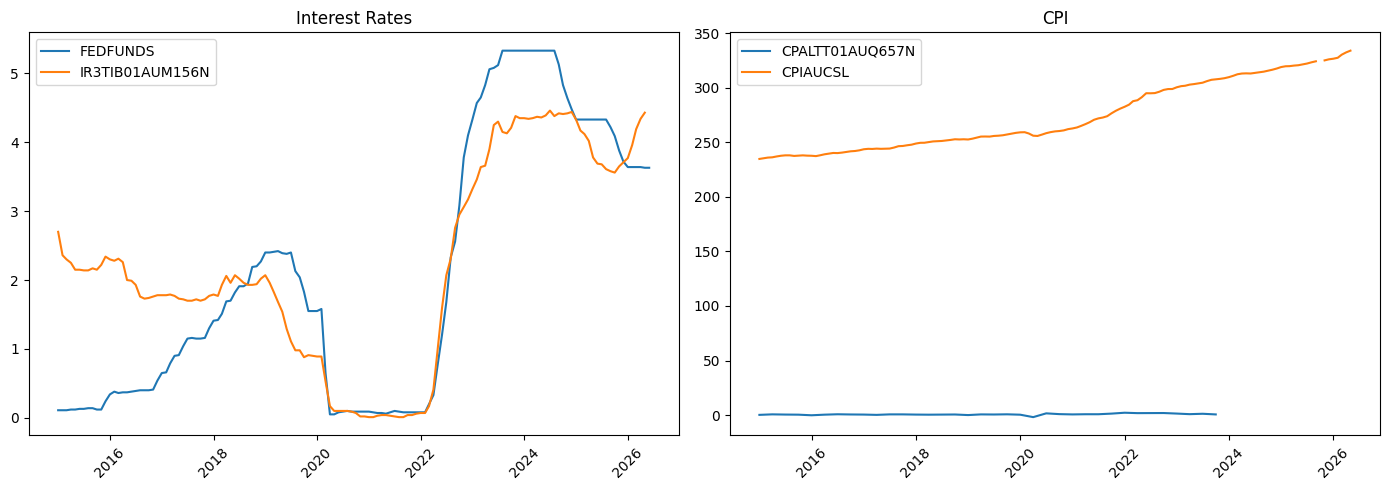

In [9]:
comparisons = {
    "Interest Rates": ["IR3TIB01AUM156N", "FEDFUNDS"],
    "CPI": ["CPALTT01AUQ657N", "CPIAUCSL"],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, ids) in zip(axes, comparisons.items()):
    subset = df[df["series_id"].isin(ids)]
    for sid, group in subset.groupby("series_id"):
        ax.plot(group["date"], group["value"], label=sid)
    ax.set_title(title)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()